# Train our own Cellpose model

In [5]:
import skimage
import numpy as np
import os
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
from cellpose import io, models, train
io.logger_setup()

2025-05-19 09:46:40,044 [INFO] WRITING LOG OUTPUT TO /home/MORGRIDGE/yren/.cellpose/run.log
2025-05-19 09:46:40,045 [INFO] 
cellpose version: 	3.1.1.1 
platform:       	linux 
python version: 	3.12.10 
torch version:  	2.6.0


(<Logger cellpose.io (INFO)>,
 PosixPath('/home/MORGRIDGE/yren/.cellpose/run.log'))

In [3]:
path = '/scr/yren/micronuclei-detection/baselines/all_data_micronuclei_no_rescale/'
train_dir = os.path.join(path, 'train')
val_dir = os.path.join(path, 'validation')

In [4]:
os.listdir(train_dir)

['C1-20X_c0_B3_Tile-5.phenotype_outlines.png',
 'C1-20X_c0_B3_Tile-5.nuclei-clean.tif',
 'C1-20X_c0_B3_Tile-5.phenotype.tif',
 'C1-20X_c0_phalloidin_C3_Tile-18.phenotype_outlines.png',
 'C1-20X_c0_phalloidin_C3_Tile-18.nuclei-clean.tif',
 'C1-20X_c0_phalloidin_C3_Tile-18.phenotype.tif',
 '20X_c0-DAPI_A1_Tile-190.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-190.nuclei-clean.tif',
 '20X_c0-DAPI_A1_Tile-190.phenotype.tif',
 'C2-20X_c0-DAPI-GFP_B2_Tile-20.phenotype_outlines.png',
 'C2-20X_c0-DAPI-GFP_B2_Tile-20.nuclei-clean.tif',
 'C2-20X_c0-DAPI-GFP_B2_Tile-20.phenotype.tif',
 '20X_c0-DAPI_A1_Tile-90.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-90.nuclei-clean.tif',
 '20X_c0-DAPI_A1_Tile-90.phenotype.tif',
 '20X_c0-DAPI_A1_Tile-70.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-70.nuclei-clean.tif',
 '20X_c0-DAPI_A1_Tile-70.phenotype.tif',
 '20X_c0-DAPI_A1_Tile-110.phenotype_outlines.png',
 '20X_c0-DAPI_A1_Tile-110.nuclei-clean.tif',
 '20X_c0-DAPI_A1_Tile-110.phenotype.tif',
 '20X_c0-D

In [5]:
output = io.load_train_test_data(train_dir, val_dir, image_filter=".phenotype",
                                mask_filter=".phenotype_outlines", look_one_level_down=False)

2025-05-13 09:16:18,229 [INFO] not all flows are present, running flow generation for all images


2025-05-13 09:16:20,188 [INFO] 121 / 121 images in /scr/yren/micronuclei-detection/baselines/all_data_micronuclei_no_rescale/train folder have labels
2025-05-13 09:16:20,194 [INFO] not all flows are present, running flow generation for all images
2025-05-13 09:16:20,577 [INFO] 47 / 47 images in /scr/yren/micronuclei-detection/baselines/all_data_micronuclei_no_rescale/validation folder have labels


In [6]:
images, labels, image_names, test_images, test_labels, image_names_test = output

In [7]:
print(len(images))

121


In [8]:
model = models.CellposeModel(gpu=True, model_type='cyto3')

2025-05-13 09:16:20,623 [INFO] >> cyto3 << model set to be used


2025-05-13 09:16:21,083 [INFO] ** TORCH CUDA version installed and working. **
2025-05-13 09:16:21,084 [INFO] >>>> using GPU (CUDA)
2025-05-13 09:16:21,146 [INFO] >>>> loading model /home/MORGRIDGE/yren/.cellpose/models/cyto3
2025-05-13 09:16:21,199 [INFO] >>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)


In [9]:
channels = [0,0]

In [10]:
print(images[0].shape)

(2960, 2960)


In [11]:
save_path = '/scr/yren/micronuclei-detection/baselines/cellpose_models/'
model_path, train_losses, test_losses = train.train_seg(
    model.net,
    train_data=images,
    train_labels=labels,
    channels=[0, 0],              # Use first channel (grayscale)
    channel_axis=None,            # No channel dimension in your data
    weight_decay=1e-6,
    learning_rate=1e-5,
    n_epochs=100,
    normalize=True,
    model_name="finetuned_cellpose.pth",
    save_path=save_path
)

2025-05-13 09:16:21,246 [INFO] computing flows for labels


100%|██████████| 121/121 [00:19<00:00,  6.06it/s]

2025-05-13 09:16:41,575 [INFO] >>> computing diameters



100%|██████████| 121/121 [00:00<00:00, 183.00it/s]

2025-05-13 09:16:42,238 [WARNING] 30 train images with number of masks less than min_train_masks (5), removing from train set
2025-05-13 09:16:42,239 [INFO] >>> using channels [0, 0]
2025-05-13 09:16:42,239 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2025-05-13 09:16:47,021 [INFO] >>> n_epochs=100, n_train=91, n_test=None
2025-05-13 09:16:47,021 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00000
2025-05-13 09:16:47,851 [INFO] >>> saving model to /scr/yren/micronuclei-detection/baselines/cellpose_models/models/finetuned_cellpose.pth
2025-05-13 09:16:51,165 [INFO] 0, train_loss=1.3463, test_loss=0.0000, LR=0.000000, time 3.31s
2025-05-13 09:17:03,125 [INFO] 5, train_loss=1.2578, test_loss=0.0000, LR=0.000006, time 15.27s
2025-05-13 09:17:14,576 [INFO] 10, train_loss=1.3052, test_loss=0.0000, LR=0.000010, time 26.72s
2025-05-13 09:17:37,874 [INFO] 20, train_loss=1.2247, test_loss=0.0000, LR=0.000010, time 50.02s
2025-05-13 09:18:00,612 [INFO] 30, train_loss=1.2417, test_loss=0.0000, LR=0.000010, time 72.76s
2025-05-13 09:18:23,859 [INFO] 40, train_loss=1.2202, test_loss=0.0000, LR=0.000010, time 96.01s
2025-05-13 09:18:47,903 [INFO] 50, train_loss=1.1325, test_loss=0.0000, LR=0.000010, time 120.05s
2025-05-13 09:19:11,220 [

In [13]:
diam_labels = model.diam_labels.copy()
diam_labels

30.0

- Test on non cropped images

In [14]:
images_dir = '/scr/yren/micronuclei-detection/baselines/all_data_micronuclei_no_rescale/validation/'
file_names = [x for x in os.listdir(images_dir) if x.endswith(".phenotype.tif")]
input_files = [f"{images_dir}/{x}" for x in file_names]
input_files[0:3]

['/scr/yren/micronuclei-detection/baselines/all_data_micronuclei_no_rescale/validation//IXMtest_F22_s6_w1F4C7ADE4-B68D-4D30-A063-722B87AA2DA1.phenotype.tif',
 '/scr/yren/micronuclei-detection/baselines/all_data_micronuclei_no_rescale/validation//IXMtest_L05_s2_w1B9C6FAC9-9D48-4184-8D9B-ABFC3BEC1125.phenotype.tif',
 '/scr/yren/micronuclei-detection/baselines/all_data_micronuclei_no_rescale/validation//IXMtest_B04_s4_w1F6AEFA0F-AF87-4B3B-A334-698647CFE043.phenotype.tif']

In [15]:
test_images = [io.imread(f) for f in input_files]

In [16]:
masks = model.eval(test_images,
                   channels=[0,0],
                   diameter=diam_labels)[0]

2025-05-13 09:21:15,397 [INFO] 100%|##########| 47/47 [00:23<00:00,  2.03it/s]


In [171]:
for i in range(len(masks)):
    H,W = masks[i].shape
    if H > 2000:
        print(i)

29
30
31
32
33


In [17]:
print(len(np.unique(masks[29])) - 1)

1080


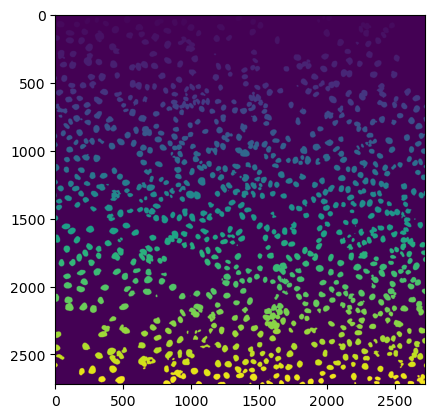

In [18]:
plt.imshow(masks[29])

In [20]:
regions = skimage.measure.regionprops(masks[29])
regions[0].area

241.0

In [21]:
region = regions[0]  # access the first region
print(region.centroid)        # (row, col) of the region center
print(region.area)                   # number of pixels
print(region.bbox)                   # bounding box: (min_row, min_col, max_row, max_col)
print(region.label)                 # label number in the mask

(6.08298755186722, 7.838174273858921)
241.0
(0, 0, 16, 20)
1


In [173]:
MICRON_AREA_THRESHOLD = 100

labels = skimage.morphology.label(masks[29])
micron_labels = []
for i in range(1, len(np.unique(labels))):
    area = np.sum(labels == i)
    if area < MICRON_AREA_THRESHOLD:
        micron_labels.append(i)
        
micro_mask = np.zeros_like(masks[29])
for i in micron_labels:
    micro_mask += (labels == i)

In [174]:
print(np.unique(micro_mask))

[0 1]


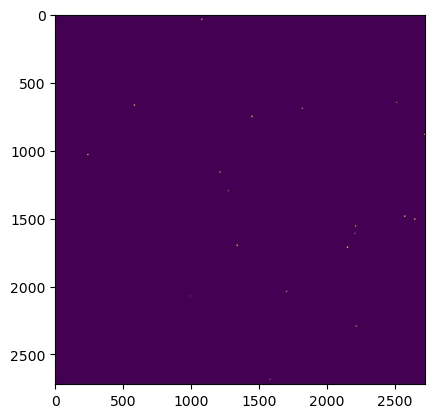

In [175]:
plt.imshow(micro_mask)

# Check if 200 threshold makes sense or not

In [26]:
cp_pred_path = '/scr/yren/micronuclei-detection/baselines/cellpose_predictions/'
files = os.listdir(cp_pred_path)
files[0:5]

['2022-05-26_RPE1-2198._probabilities.npy',
 '2022-10-14_U2OS-1._probabilities.npy',
 '2023-05-31_misc-4._probabilities.npy',
 '20X_c0-DAPI_A1_Tile-50._probabilities.npy',
 'C1-20X_c0_B3_Tile-24._probabilities.npy']

In [27]:
pred = np.load(cp_pred_path + '20X_c0-DAPI_A1_Tile-50._probabilities.npy')
print(pred.shape)

(2960, 2960)


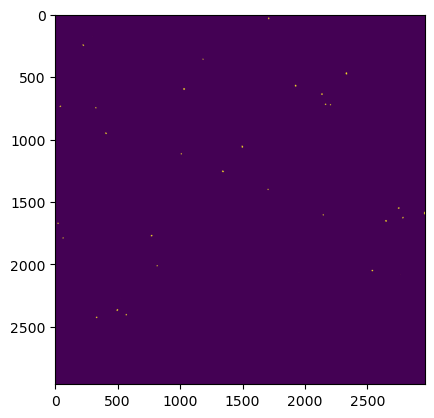

In [28]:
plt.imshow(pred)

In [3]:
from mnfinder import MNClassifier
import skimage
import numpy as np
import matplotlib.pyplot as plt

In [5]:
path = '/scr/yren/all_data_micronuclei_no_rescale/validation/'
imid = 'IXMtest_F22_s6_w1F4C7ADE4-B68D-4D30-A063-722B87AA2DA1'
bbbc039_path = path + f'{imid}.phenotype.tif'

In [6]:
attention_model = MNClassifier.get_model('Attention')
im = skimage.io.imread(bbbc039_path)
print(im.shape)

(520, 696)


In [7]:
labels = attention_model.predict(im)
micro_labels = labels[:,:,2]

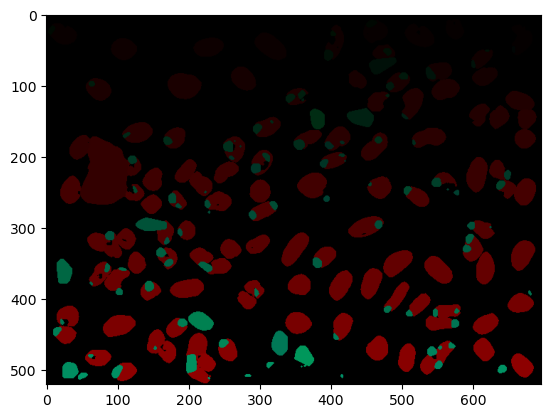

In [10]:
plt.imshow(labels)

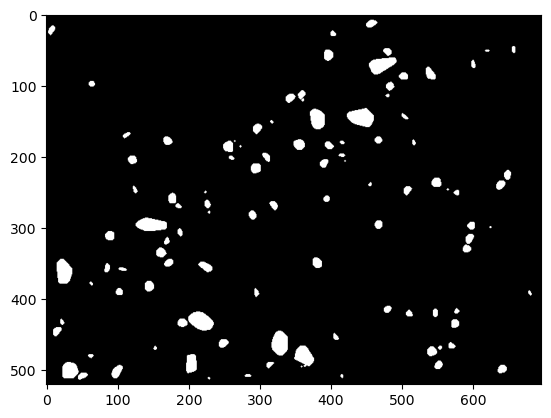

In [13]:
plt.imshow(micro_labels > 0, cmap='gray')

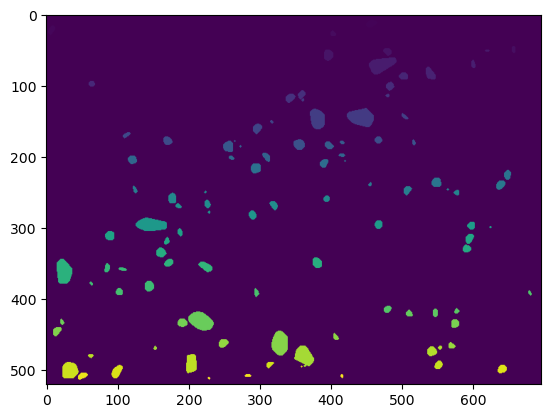

In [16]:
plt.imshow(labels[:,:,2])

# Re-train a pilot_screen specialist model

In [50]:
specialist = 'mnfinder_train'

In [51]:
CURRENT_PATH = os.getcwd()
DIRECTORY = CURRENT_PATH + '/all_data_micronuclei_no_rescale/train'

# Train
files = os.listdir(DIRECTORY)
filelist = [file for file in files if not file.startswith('.')] # avoid files starting with . when untarring in CHTC
annot_files = [x for x in filelist if x.endswith('.phenotype_outlines.png')]
annot_files.sort()
training_files = annot_files.copy()

In [52]:
df = pd.read_csv(CURRENT_PATH + '/all_data_micronuclei_no_rescale/metadata.csv')
if specialist == 'pilot_screen':
    files_to_keep = df[(df.datasets.isin(['pilot', 'screen'])) & (df.split == 'train')].filenames.to_list()
elif specialist == 'hela_rpe1':
    files_to_keep = df[(df.datasets.isin(['HeLa', 'RPE1'])) & (df.split == 'train')].filenames.to_list()
else:
    files_to_keep = df[(df.datasets.isin([specialist])) & (df.split == 'train')].filenames.to_list()
    

fn = lambda file: file.replace('phenotype.tif', 'phenotype_outlines.png')
new_training_files = [fn(file) for file in files_to_keep]
print(len(new_training_files))

30


In [53]:
new_training_files[:5]

['2022-05-27_RPE1-3.phenotype_outlines.png',
 '2022-05-27_RPE1-1.phenotype_outlines.png',
 '2022-05-27_RPE1-2197.phenotype_outlines.png',
 '2022-03-18_RPE1-3.phenotype_outlines.png',
 '2022-03-18_RPE1-5.phenotype_outlines.png']

In [54]:
fn2 = lambda file: file.replace('phenotype_outlines.png', 'phenotype.tif')
inputs = [fn2(file) for file in new_training_files]
inputs[:5]

['2022-05-27_RPE1-3.phenotype.tif',
 '2022-05-27_RPE1-1.phenotype.tif',
 '2022-05-27_RPE1-2197.phenotype.tif',
 '2022-03-18_RPE1-3.phenotype.tif',
 '2022-03-18_RPE1-5.phenotype.tif']

In [55]:
path = CURRENT_PATH + '/all_data_micronuclei_no_rescale/train/'
imgs = [io.imread(path + f) for f in inputs]
gts = [io.imread(path + f) for f in new_training_files]

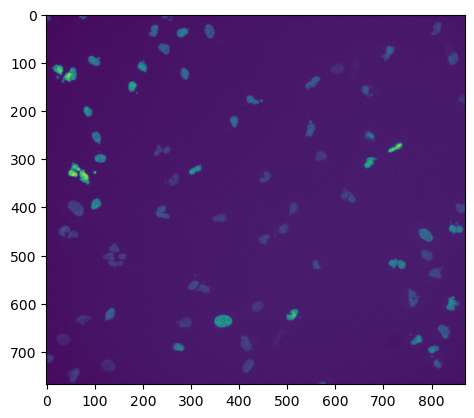

In [56]:
plt.imshow(imgs[6])

In [66]:
np.unique(gts[3])

array([0, 1], dtype=uint8)

In [67]:
model = models.CellposeModel(gpu=True, model_type='cyto3')
channels = [0,0]

save_path = '/scr/yren/micronuclei-detection/baselines/cellpose_models/'
model_path, train_losses, test_losses = train.train_seg(
    model.net,
    train_data=imgs,
    train_labels=gts,
    channels=[0, 0],              # Use first channel (grayscale)
    channel_axis=None,            # No channel dimension in your data
    weight_decay=1e-6,
    learning_rate=1e-5,
    n_epochs=100,
    normalize=True,
    # model_name="cellpose_pliot_screen_specialist.pth",
    save_path=save_path,
    min_train_masks=0
)

2025-05-19 11:32:10,371 [INFO] >> cyto3 << model set to be used
2025-05-19 11:32:10,372 [INFO] ** TORCH CUDA version installed and working. **
2025-05-19 11:32:10,372 [INFO] >>>> using GPU (CUDA)
2025-05-19 11:32:10,414 [INFO] >>>> loading model /home/MORGRIDGE/yren/.cellpose/models/cyto3
2025-05-19 11:32:10,466 [INFO] >>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
2025-05-19 11:32:10,467 [INFO] computing flows for labels


100%|██████████| 30/30 [00:11<00:00,  2.69it/s]

2025-05-19 11:32:21,657 [INFO] >>> computing diameters



100%|██████████| 30/30 [00:00<00:00, 386.30it/s]

2025-05-19 11:32:21,737 [INFO] >>> using channels [0, 0]
2025-05-19 11:32:21,737 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2025-05-19 11:32:22,263 [INFO] >>> n_epochs=100, n_train=30, n_test=None
2025-05-19 11:32:22,264 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00000
2025-05-19 11:32:22,265 [INFO] >>> saving model to /scr/yren/micronuclei-detection/baselines/cellpose_models/models/cellpose_1747672342.2653842
2025-05-19 11:32:22,771 [INFO] 0, train_loss=0.8690, test_loss=0.0000, LR=0.000000, time 0.51s
2025-05-19 11:32:25,146 [INFO] 5, train_loss=0.9181, test_loss=0.0000, LR=0.000006, time 2.88s
2025-05-19 11:32:27,263 [INFO] 10, train_loss=0.8972, test_loss=0.0000, LR=0.000010, time 5.00s
2025-05-19 11:32:31,704 [INFO] 20, train_loss=0.8650, test_loss=0.0000, LR=0.000010, time 9.44s
2025-05-19 11:32:37,184 [INFO] 30, train_loss=0.8890, test_loss=0.0000, LR=0.000010, time 14.92s
2025-05-19 11:32:43,366 [INFO] 40, train_loss=0.8630, test_loss=0.0000, LR=0.000010, time 21.10s
2025-05-19 11:32:50,487 [INFO] 50, train_loss=0.8829, test_loss=0.0000, LR=0.000010, time 28.22s
2025-05-19 11:32:57,020 

In [20]:
diam_labels = model.diam_labels.copy()
diam_labels

30.0

In [18]:
images_dir = '/scr/yren/micronuclei-detection/baselines/all_data_micronuclei_no_rescale/validation/'
file_names = [x for x in os.listdir(images_dir) if x.endswith(".phenotype.tif")]
input_files = [f"{images_dir}/{x}" for x in file_names]
input_files[0:3]

test_images = [io.imread(f) for f in input_files]

In [21]:
masks = model.eval(test_images,
                   channels=[0,0],
                   diameter=diam_labels)[0]

2025-05-19 10:00:31,659 [INFO] 100%|##########| 47/47 [00:22<00:00,  2.05it/s]


In [25]:
print(len(np.unique(masks[29])) - 1)

1151


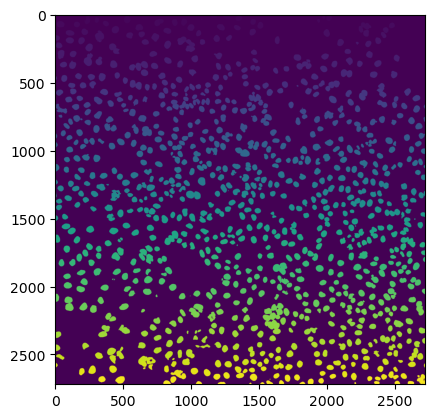

In [26]:
plt.imshow(masks[29])

In [28]:
region = regions[0]  # access the first region
print(region.centroid)        # (row, col) of the region center
print(region.area)                   # number of pixels
print(region.bbox)                   # bounding box: (min_row, min_col, max_row, max_col)
print(region.label)                 # label number in the mask

(6.078512396694215, 7.880165289256198)
242.0
(0, 0, 16, 20)
1


In [47]:
MICRON_AREA_THRESHOLD = 300

labels = skimage.morphology.label(masks[29])
micron_labels = []
for i in range(1, len(np.unique(labels))):
    area = np.sum(labels == i)
    if area < MICRON_AREA_THRESHOLD:
        micron_labels.append(i)
        
micro_mask = np.zeros_like(masks[29])
for i in micron_labels:
    micro_mask += (labels == i)

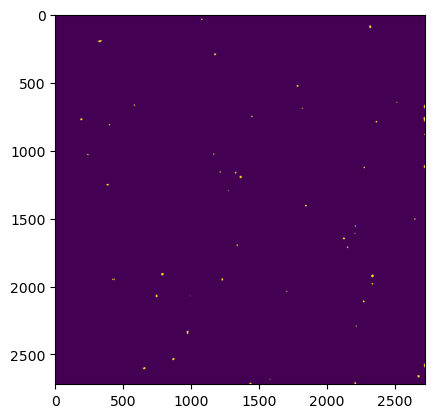

In [48]:
plt.imshow(micro_mask)